In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,classification_report,roc_auc_score,precision_score,recall_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


In [3]:

# Load the shared clean data and split data
x_train=pd.read_csv("../output/x_train.csv")
x_test=pd.read_csv("../output/x_test.csv")
y_train=pd.read_csv("../output/y_train.csv").squeeze()
y_test=pd.read_csv("../output/y_test.csv").squeeze()
# we use squeeze for y_train and y_test because both of these files
# only have 1 column
# so .squeeze() helps us convert from 1 column DataFrame to a series
# this one helps us get the target variable as a 1-dimension
# because we only need values, makes cleaner

In [4]:
the_scaler = StandardScaler()
scaled_X_train = the_scaler.fit_transform(x_train)
scaled_X_test = the_scaler.transform(x_test)

In [5]:
# create random_forest_model
random_forest_model=RandomForestClassifier(n_estimators=100,random_state=42)

# train the random_forest model
# we let random forest model learn from training dataset in order to predict
# on unseen data
random_forest_model.fit(x_train,y_train)

#predict
predicted_random_forest_model=random_forest_model.predict(x_test)

In [6]:
# evaluate the model
accuracy=accuracy_score(y_test,predicted_random_forest_model)
confusion_matrix_value=confusion_matrix(y_test,predicted_random_forest_model)
f1=f1_score(y_test,predicted_random_forest_model,average="weighted")
precision=precision_score(y_test,predicted_random_forest_model,average="weighted",zero_division=0)
recall=recall_score(y_test,predicted_random_forest_model,average="weighted",zero_division=0)

print("Accuracy score: ",accuracy)
print("Confusion matrix: ",confusion_matrix_value)
print("F1_score: ",f1)
print("Precision Score: ",precision)
print("Recall Score: ",recall)
# ROC-AUC score
predicted_random_forest_probabilities = random_forest_model.predict_proba(x_test)
classes = sorted(y_train.unique())
y_test_binary = label_binarize(y_test, classes=classes)

roc_auc = roc_auc_score(
    y_test_binary,
    predicted_random_forest_probabilities,
    multi_class="ovr",
    average="weighted"
)

print("\n Classification Report")
print(classification_report(y_test,predicted_random_forest_model,zero_division=0))
print("ROC-AUC Score: ",roc_auc)

Accuracy score:  0.625
Confusion matrix:  [[ 0  1  1  0  0  0]
 [ 0  0  8  3  0  0]
 [ 0  1 84 29  2  0]
 [ 0  0 25 74  8  0]
 [ 0  0  4 16 12  1]
 [ 0  0  0  2  1  0]]
F1_score:  0.6050710391108316
Precision Score:  0.5916951561508883
Recall Score:  0.625

 Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.72      0.71       116
           6       0.60      0.69      0.64       107
           7       0.52      0.36      0.43        33
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.30      0.30       272
weighted avg       0.59      0.62      0.61       272

ROC-AUC Score:  0.7802647422936695


In [7]:
# make csv file for evaluation
random_forest_result=pd.DataFrame({
    "Model":["Random Forest"],
    "Accuracy Score":[accuracy],
    "Precision Score":[precision],
    "Recall Score":[recall],
    "F1-Score":[f1],
    "ROC-AUC: ":[roc_auc]
})
random_forest_result.to_csv("../output/random_forest_result.csv",index=False)

                 Feature  Importance
10               alcohol    0.151170
9              sulphates    0.112418
1       volatile acidity    0.104158
6   total sulfur dioxide    0.101988
7                density    0.088841
4              chlorides    0.083185
8                     pH    0.076974
2            citric acid    0.072353
0          fixed acidity    0.071868
3         residual sugar    0.069737
5    free sulfur dioxide    0.067309


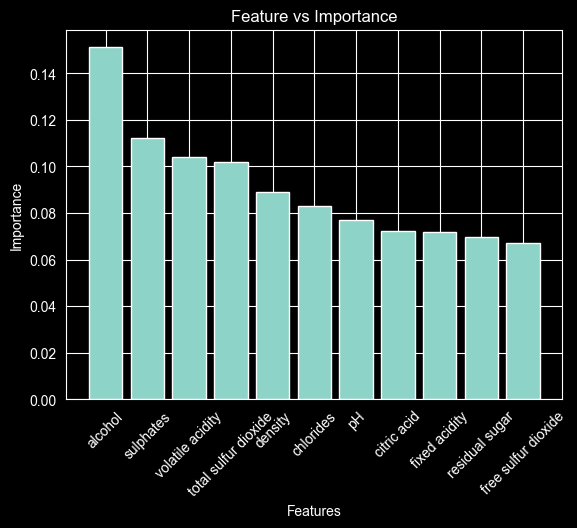

In [8]:
# feature importance
importances=random_forest_model.feature_importances_
feature_importances=pd.DataFrame({
    "Feature":x_train.columns,
    "Importance":importances
})
feature_importances=feature_importances.sort_values(by="Importance",ascending=False)
print(feature_importances)

plt.figure()
plt.title("Feature vs Importance")
plt.bar(feature_importances["Feature"],feature_importances["Importance"])
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.show()